# Bland–Altman Plot

✔ 1. Basic Bland–Altman Plot

✔ 2. Bland–Altman With 95% Limits of Agreement

✔ 3. Bland–Altman With Proportional Bias Line (Regression)

✔ 4. Bland–Altman For Repeated Measurements

✔ 5. Log-Transformed Bland–Altman (for ratio data)

✔ 6. Professional Styled Version

## Basic Bland–Altman Plot

Two measurement methods: A and B.

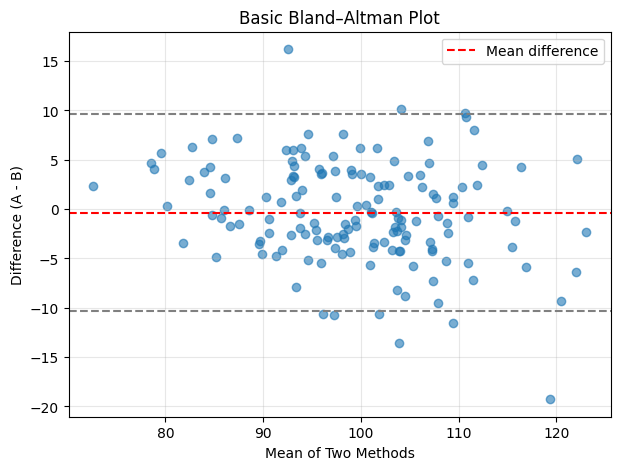

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Two measurement methods
A = np.random.normal(100, 10, 150)
B = A + np.random.normal(0, 5, 150)

# Mean & difference
mean_vals = (A + B) / 2
diff_vals = A - B

plt.figure(figsize=(7, 5))
plt.scatter(mean_vals, diff_vals, alpha=0.6)

plt.axhline(np.mean(diff_vals), color='red', linestyle='--', label="Mean difference")
plt.axhline(np.mean(diff_vals) + 1.96*np.std(diff_vals), color='gray', linestyle='--')
plt.axhline(np.mean(diff_vals) - 1.96*np.std(diff_vals), color='gray', linestyle='--')

plt.xlabel("Mean of Two Methods")
plt.ylabel("Difference (A - B)")
plt.title("Basic Bland–Altman Plot")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Bland–Altman with 95% Limits of Agreement (LOA)

This is the official medical/statistics format.

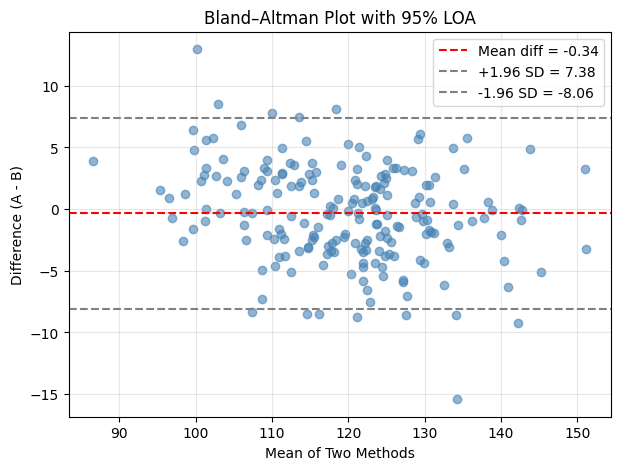

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
A = np.random.normal(120, 12, 200)
B = A + np.random.normal(0, 4, 200)

mean_vals = (A + B) / 2
diff_vals = A - B

mean_diff = np.mean(diff_vals)
sd_diff = np.std(diff_vals)

loa_upper = mean_diff + 1.96 * sd_diff
loa_lower = mean_diff - 1.96 * sd_diff

plt.figure(figsize=(7, 5))
plt.scatter(mean_vals, diff_vals, alpha=0.6, color='steelblue')

plt.axhline(mean_diff, color='red', linestyle='--', label=f"Mean diff = {mean_diff:.2f}")
plt.axhline(loa_upper, color='gray', linestyle='--', label=f"+1.96 SD = {loa_upper:.2f}")
plt.axhline(loa_lower, color='gray', linestyle='--', label=f"-1.96 SD = {loa_lower:.2f}")

plt.xlabel("Mean of Two Methods")
plt.ylabel("Difference (A - B)")
plt.title("Bland–Altman Plot with 95% LOA")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Bland–Altman with Proportional Bias (Regression Line)

If the difference depends on measurement magnitude → bias exists.

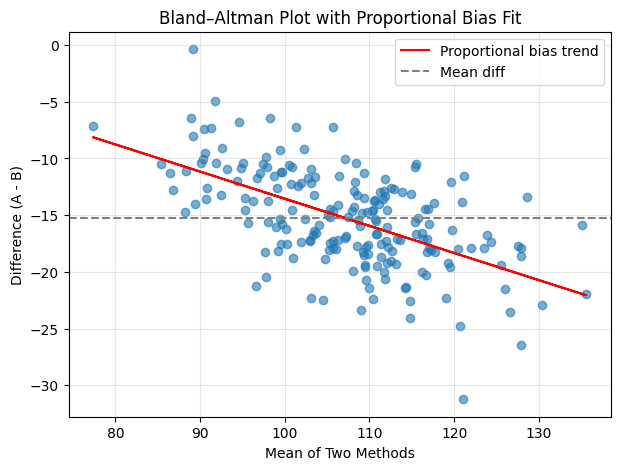

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

A = np.random.normal(100, 10, 200)
B = A + 0.15 * A + np.random.normal(0, 4, 200)  # proportional error

mean_vals = (A + B) / 2
diff_vals = A - B

# Linear regression
reg = LinearRegression()
reg.fit(mean_vals.reshape(-1, 1), diff_vals)
trend = reg.predict(mean_vals.reshape(-1, 1))

plt.figure(figsize=(7, 5))
plt.scatter(mean_vals, diff_vals, alpha=0.6)

plt.plot(mean_vals, trend, 'r', label="Proportional bias trend")

plt.axhline(np.mean(diff_vals), color='gray', linestyle='--', label="Mean diff")

plt.xlabel("Mean of Two Methods")
plt.ylabel("Difference (A - B)")
plt.title("Bland–Altman Plot with Proportional Bias Fit")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Log-Transformed Bland–Altman (Ratio Data)

Use when devices differ by a constant ratio, not a constant difference.

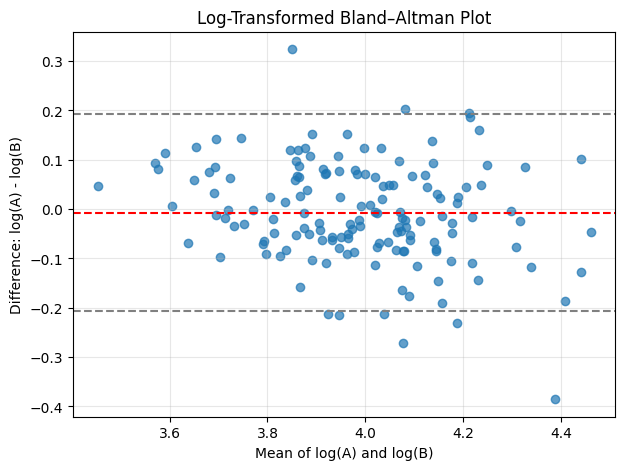

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

A = np.random.lognormal(mean=4, sigma=0.2, size=150)
B = A * np.random.lognormal(mean=0, sigma=0.1, size=150)

logA = np.log(A)
logB = np.log(B)

mean_vals = (logA + logB) / 2
diff_vals = logA - logB

mean_diff = np.mean(diff_vals)
sd_diff = np.std(diff_vals)

plt.figure(figsize=(7, 5))
plt.scatter(mean_vals, diff_vals, alpha=0.7)

plt.axhline(mean_diff, color='red', linestyle='--')
plt.axhline(mean_diff + 1.96 * sd_diff, color='gray', linestyle='--')
plt.axhline(mean_diff - 1.96 * sd_diff, color='gray', linestyle='--')

plt.xlabel("Mean of log(A) and log(B)")
plt.ylabel("Difference: log(A) - log(B)")
plt.title("Log-Transformed Bland–Altman Plot")
plt.grid(alpha=0.3)
plt.show()


## Publication-Ready Bland–Altman Plot (Styled)

This is the best-looking, journal-quality format.

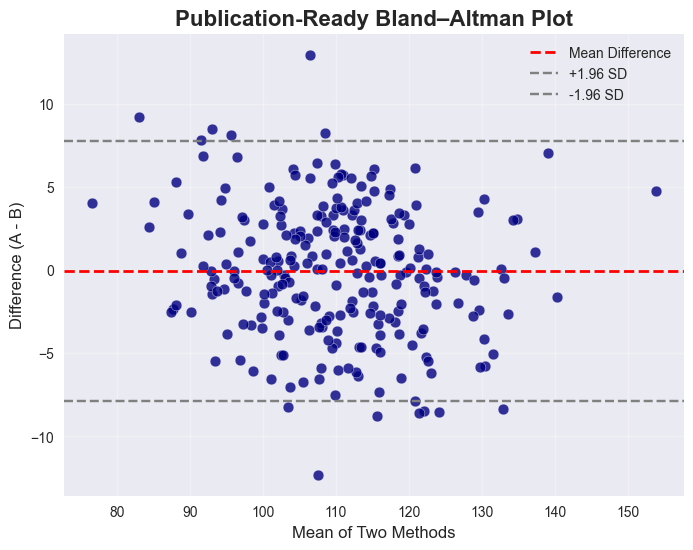

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

np.random.seed(42)
A = np.random.normal(110, 12, 250)
B = A + np.random.normal(0, 4, 250)

mean_vals = (A + B) / 2
diff_vals = A - B

mean_diff = np.mean(diff_vals)
sd_diff = np.std(diff_vals)
loa_upper = mean_diff + 1.96 * sd_diff
loa_lower = mean_diff - 1.96 * sd_diff

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(mean_vals, diff_vals, color='navy', edgecolor='white', alpha=0.8, s=60)

ax.axhline(mean_diff, color='red', linestyle='--', linewidth=2, label='Mean Difference')
ax.axhline(loa_upper, color='gray', linestyle='--', label='+1.96 SD')
ax.axhline(loa_lower, color='gray', linestyle='--', label='-1.96 SD')

ax.set_xlabel("Mean of Two Methods", fontsize=12)
ax.set_ylabel("Difference (A - B)", fontsize=12)
ax.set_title("Publication-Ready Bland–Altman Plot", fontsize=16, fontweight='bold')

ax.grid(alpha=0.3)
ax.legend()

plt.show()
